In [72]:
import requests
import json
import noaa_sdk
import cartopy
import metpy
from matplotlib import pyplot as plt
from cartopy.io.img_tiles import GoogleTiles, OSM


## Overview
   
Within this notebook, we will cover:

1. Explore quering the NWS API with the NOAA SDK
1. Show how you can use the zone API to get a polygon
1. Plot polygons on a map using Cartopy


## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy.html) | Helpful | Basic features |

- **Time to learn**: 45 minutes
---

In [50]:
API = noaa_sdk.NOAA()
active_alerts =API.alerts(active=1)

Lets look at the structure:

In [54]:
print(active_alerts.keys())
len(active_alerts['features'])

dict_keys(['@context', 'type', 'features', 'title', 'updated'])


229

There are 229 active alerts across the USA, lets look at one.

In [58]:
print(active_alerts['features'][20].keys())
print(active_alerts['features'][20]['properties'].keys())


dict_keys(['id', 'type', 'geometry', 'properties'])
dict_keys(['@id', '@type', 'id', 'areaDesc', 'geocode', 'affectedZones', 'references', 'sent', 'effective', 'onset', 'expires', 'ends', 'status', 'messageType', 'category', 'severity', 'certainty', 'urgency', 'event', 'sender', 'senderName', 'headline', 'description', 'instruction', 'response', 'parameters', 'scope', 'code', 'language', 'web', 'eventCode'])


Cool! Lets look at what and where it is. 

In [60]:
print(active_alerts['features'][20]['properties']['event'])
print(active_alerts['features'][20]['properties']['affectedZones'])

Heat Advisory
['https://api.weather.gov/zones/forecast/NCZ023', 'https://api.weather.gov/zones/forecast/NCZ073', 'https://api.weather.gov/zones/forecast/NCZ074', 'https://api.weather.gov/zones/forecast/NCZ083', 'https://api.weather.gov/zones/forecast/NCZ084']


Cool! So this is a Heat Advisory (of course this will probably change as this is real time). The areas affected are zones.. The zone polygons can be fetched using the api!

In [64]:
#Lets do an API call
polygon = requests.get(active_alerts['features'][20]['properties']['affectedZones'][0]).json()
print(polygon.keys())
print(polygon['properties'])


dict_keys(['@context', 'id', 'type', 'geometry', 'properties'])
{'@id': 'https://api.weather.gov/zones/forecast/NCZ023', '@type': 'wx:Zone', 'id': 'NCZ023', 'type': 'public', 'name': 'Alamance', 'effectiveDate': '2025-03-18T18:00:00+00:00', 'expirationDate': '2200-01-01T00:00:00+00:00', 'state': 'NC', 'forecastOffice': 'https://api.weather.gov/offices/RAH', 'gridIdentifier': 'RAH', 'awipsLocationIdentifier': 'RAH', 'cwa': ['RAH'], 'forecastOffices': ['https://api.weather.gov/offices/RAH'], 'timeZone': ['America/New_York'], 'observationStations': ['https://api.weather.gov/stations/KBUY', 'https://api.weather.gov/stations/KGSO', 'https://api.weather.gov/stations/KHBI', 'https://api.weather.gov/stations/KINT', 'https://api.weather.gov/stations/KRDU', 'https://api.weather.gov/stations/KTDF'], 'radarStation': 'RAX'}


In [65]:
print(polygon['geometry'])


{'type': 'Polygon', 'coordinates': [[[-79.2563934, 36.2439117], [-79.25709529999999, 36.2399139], [-79.25709529999999, 36.2377128], [-79.25779719999998, 36.2256126], [-79.25769799999999, 36.2156105], [-79.2584991, 36.1852111], [-79.2591934, 36.1466102], [-79.2595977, 36.134612999999995], [-79.2602996, 36.10001369999999], [-79.26059719999999, 36.093112899999994], [-79.260498, 36.08531179999999], [-79.2608947, 36.07531349999999], [-79.26179499999999, 36.059512999999995], [-79.2616958, 36.048911999999994], [-79.2630996, 36.003513299999995], [-79.2634963, 35.9673118], [-79.2644958, 35.914111999999996], [-79.263298, 35.9069137], [-79.25929260000001, 35.9043121], [-79.25719450000001, 35.9017105], [-79.25759880000001, 35.8984107], [-79.25829310000002, 35.8946113], [-79.25749960000002, 35.890213], [-79.25619500000002, 35.8863105], [-79.25419610000002, 35.883113800000004], [-79.25089260000001, 35.8796119], [-79.24949640000001, 35.8770103], [-79.2495956, 35.874912200000004], [-79.2509002, 35.872

Lets write a simple function to parse this out into lons and lats

In [ ]:
def get_zone(zone):
    polygon = requests.get(zone).json()
    line = polygon['geometry']['coordinates'][0]
    lats = []
    lons = []
    for point in line:
        lats.append(point[1])
        lons.append(point[0])

    return lons, lats

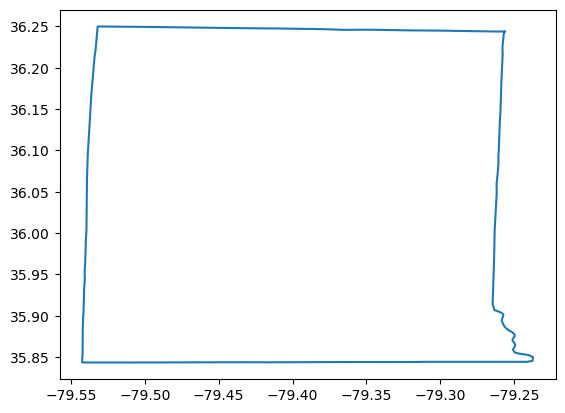

In [68]:
#Lets look at one of the zones!
zone_lons, zone_lats = get_zone(active_alerts['features'][20]['properties']['affectedZones'][0])
fig = plt.figure()
plt.plot(zone_lons, zone_lats)

Lets look at all the affected zones and plot it on a nice map

(-80.56964981999995, -79.17364377999999, 34.732657555, 36.32226634500001)


(-80.56964981999995, -79.17364377999999, 34.732657555, 36.32226634500001)

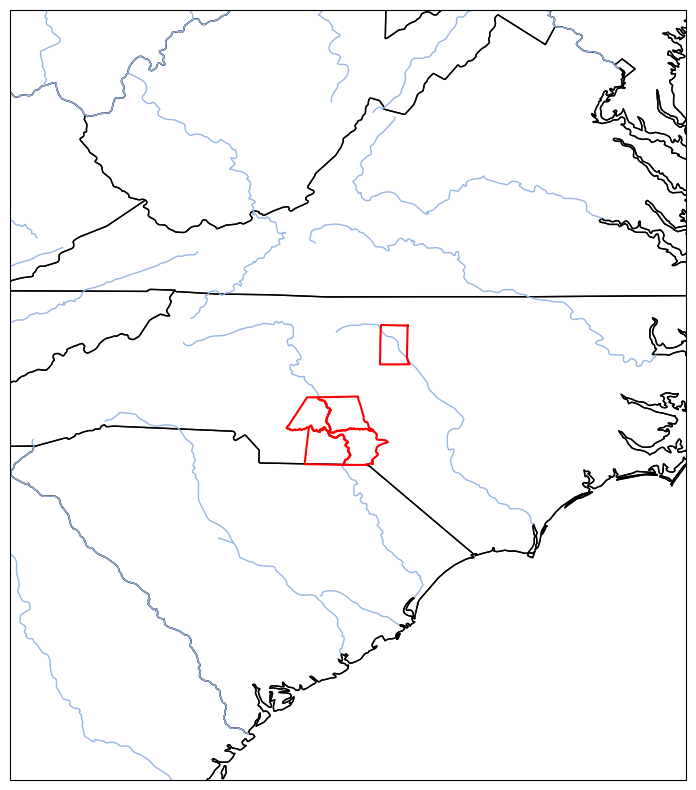

In [92]:
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(1, 1, 1, projection=cartopy.crs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.STATES)
ax.add_feature(cartopy.feature.RIVERS)


for this_zone in active_alerts['features'][20]['properties']['affectedZones']:
    this_polygon = get_zone(this_zone)
    ax.plot(this_polygon[0], this_polygon[1], color='r')

#Lets zoom out a bit
plate_carree_extent = ax.get_extent(crs=cartopy.crs.PlateCarree())
print(plate_carree_extent)

lon_extent = plate_carree_extent[0] - plate_carree_extent[1]
lat_extent = plate_carree_extent[2] - plate_carree_extent[3]
zoom = 4.0

new_extent = [0,0,0,0]
new_extent[0] = plate_carree_extent[0] - lon_extent*(zoom - 1.0)
new_extent[1] = plate_carree_extent[1] + lon_extent*(zoom - 1.0)
new_extent[2] = plate_carree_extent[2] - lat_extent*(zoom - 1.0)
new_extent[3] = plate_carree_extent[3] + lat_extent*(zoom - 1.0)
ax.set_extent(new_extent, crs=cartopy.crs.PlateCarree())



Lets plot all heat advisories


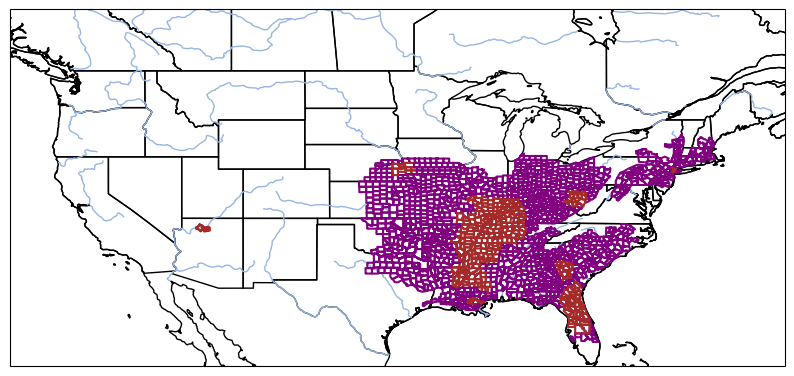

In [109]:
col_key = {'Flash Flood Warning': 'g', 'Severe Thunderstorm Warning' : 'y', 'Heat Advisory' : 'purple',
          'Air Quality Alert':'gray', 'Special Weather Statement' :'pink', 'Extreme Heat Warning' : 'brown',
          'Red Flag Warning' : 'moccasin', 'Flood Watch': 'aqua', 'Flood Warning':'green', 'Small Craft Advisory' : 'orange'}

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(1, 1, 1, projection=cartopy.crs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.STATES)
ax.add_feature(cartopy.feature.RIVERS)

for this_alert in active_alerts['features']:
    if this_alert['properties']['event'] == 'Heat Advisory' or this_alert['properties']['event'] == 'Extreme Heat Warning' :
        for this_zone in this_alert['properties']['affectedZones']:
            try:
                this_polygon = get_zone(this_zone)
                ax.plot(this_polygon[0], this_polygon[1], color=col_key[this_alert['properties']['event']])
            except:
                pass #I have not coded in multi polygons yet

ax.set_extent((-128., -65., 25., 50.))

Test Message
Fire Weather Watch
Skipping 45 Heat Advisory
Skipping 70 Heat Advisory
Skipping 72 Extreme Heat Warning
Skipping 73 Extreme Heat Warning
Fire Weather Watch
Fire Weather Watch
Skipping 94 Heat Advisory
Fire Weather Watch
Fire Weather Watch
Fire Weather Watch
Fire Weather Watch
Fire Weather Watch
Wind Advisory
High Surf Advisory
Rip Current Statement
Fire Weather Watch
Fire Weather Watch
Fire Weather Watch
Skipping 178 Heat Advisory
Skipping 192 Air Quality Alert


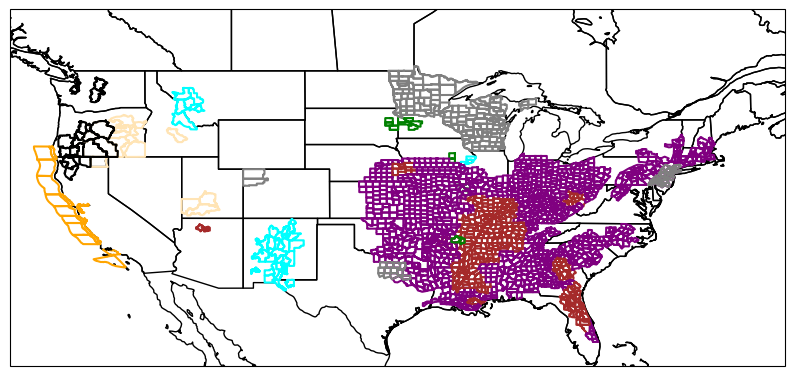

In [49]:

col_key = {'Flash Flood Warning': 'g', 'Severe Thunderstorm Warning' : 'y', 'Heat Advisory' : 'purple',
          'Air Quality Alert':'gray', 'Special Weather Statement' :'pink', 'Extreme Heat Warning' : 'brown',
          'Red Flag Warning' : 'moccasin', 'Flood Watch': 'aqua', 'Flood Warning':'green', 'Small Craft Advisory' : 'orange'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=cartopy.crs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.STATES)

for j in range(len(bactive_alerts'features'])):
    event = active_alerts['features'][j]['properties']['event']
    if event in col_key.keys():
        col = col_key[event]
    else:
        col = 'k'
        print(event)

    try:
        zones_for_warning = []
        for i in range(len(active_alerts['features'][j]['properties']['affectedZones'])):
            zones_for_warning.append(get_zone(active_alerts['features'][j]['properties']['affectedZones'][i]))
        for pgon in zones_for_warning:
            ax.plot(pgon[0], pgon[1], color=col)
    except:
        print('Skipping', j, event)

ax.set_extent((-128., -65., 25., 50.))

In [47]:
b['features'][9]['properties']
    

{'@id': 'https://api.weather.gov/alerts/urn:oid:2.49.0.1.840.0.ff8d5bf4359081b396a891b0067b8434df3e5ca4.003.1',
 '@type': 'wx:Alert',
 'id': 'urn:oid:2.49.0.1.840.0.ff8d5bf4359081b396a891b0067b8434df3e5ca4.003.1',
 'areaDesc': 'Northern New London; Southern New Haven; Southern Middlesex; Northwest Suffolk; Northeast Suffolk; Southwest Suffolk; Northern Nassau; Southern Nassau',
 'geocode': {'SAME': ['009011', '009009', '009007', '036103', '036059'],
  'UGC': ['CTZ008',
   'CTZ010',
   'CTZ011',
   'NYZ078',
   'NYZ079',
   'NYZ080',
   'NYZ177',
   'NYZ179']},
 'affectedZones': ['https://api.weather.gov/zones/forecast/CTZ008',
  'https://api.weather.gov/zones/forecast/CTZ010',
  'https://api.weather.gov/zones/forecast/CTZ011',
  'https://api.weather.gov/zones/forecast/NYZ078',
  'https://api.weather.gov/zones/forecast/NYZ079',
  'https://api.weather.gov/zones/forecast/NYZ080',
  'https://api.weather.gov/zones/forecast/NYZ177',
  'https://api.weather.gov/zones/forecast/NYZ179'],
 'refer